# Passive compliance — weight loading

How the hand's **torsional (joint-space) spring stiffness** determines the
steady-state index-finger deflection under incrementally added weights.
The finger is commanded to hold `WEIGHT_INDEX`; each weight step deflects it
further toward extension.  Higher stiffness → smaller angular deviation for
the same load.

Deviation is computed as the mean across the MCP and PIP joints
(DIP is a mimic joint, mechanically coupled to PIP).

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('../../'))
import plot_config   # auto-applies shared mplstyle
from hand_config import (
    STIFFNESS_CONDITIONS,
    WEIGHT_LABELS, WEIGHT_LOG_DURATION,
    WEIGHT_INDEX,
)

COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
OUTPUT = os.path.join('outputs', 'weight_compliance_hand')
os.makedirs(OUTPUT, exist_ok=True)

# Index finger motors: 5 = MCP, 6 = PIP  (DIP is mimic of PIP, not logged)
IDX_MOTORS = [5, 6]
N_STEPS    = 1 + len(WEIGHT_LABELS)   # 0 = no weight, 1..N = weight steps

def _synth(k):
    rng = np.random.default_rng(int(k * 1000))
    rows = []
    t = 0.0; dt = 0.02
    n = int(WEIGHT_LOG_DURATION / dt)
    for step in range(N_STEPS):
        delta = (step / (N_STEPS - 1)) * (0.3 / k)
        for _ in range(n):
            q5 = max(0.0, WEIGHT_INDEX[0] - delta       + rng.normal(0, 0.004))
            q6 = max(0.0, WEIGHT_INDEX[1] - delta * 0.6 + rng.normal(0, 0.004))
            row = {'time_s': f'{t:.3f}', 'k_rot': k, 'weight_step': step,
                   'q_5': f'{q5:.5f}', 'q_6': f'{q6:.5f}',
                   'qdot_5': '0', 'qdot_6': '0', 'tau_5': '0', 'tau_6': '0'}
            rows.append(row); t += dt
    return pd.DataFrame(rows)

DEMO = False
def load(k):
    global DEMO
    path = os.path.join(OUTPUT, f'data_K{k:.3f}.csv')
    if os.path.isfile(path):
        return pd.read_csv(path)
    DEMO = True
    return _synth(k)

DATA = {k: load(k) for k in STIFFNESS_CONDITIONS}
banner = ' DEMO (synthetic) data ' if DEMO else ' measured data '
print(f'Loaded{banner}|  K levels: {STIFFNESS_CONDITIONS}')


Loaded measured data |  K levels: [0.05, 0.3]


## Cumulative joint deviation vs weight step

Each curve is one stiffness condition.  Value = $|\Delta\theta_\mathrm{MCP}| + |\Delta\theta_\mathrm{PIP}|$, where deviation is measured from the no-weight baseline.

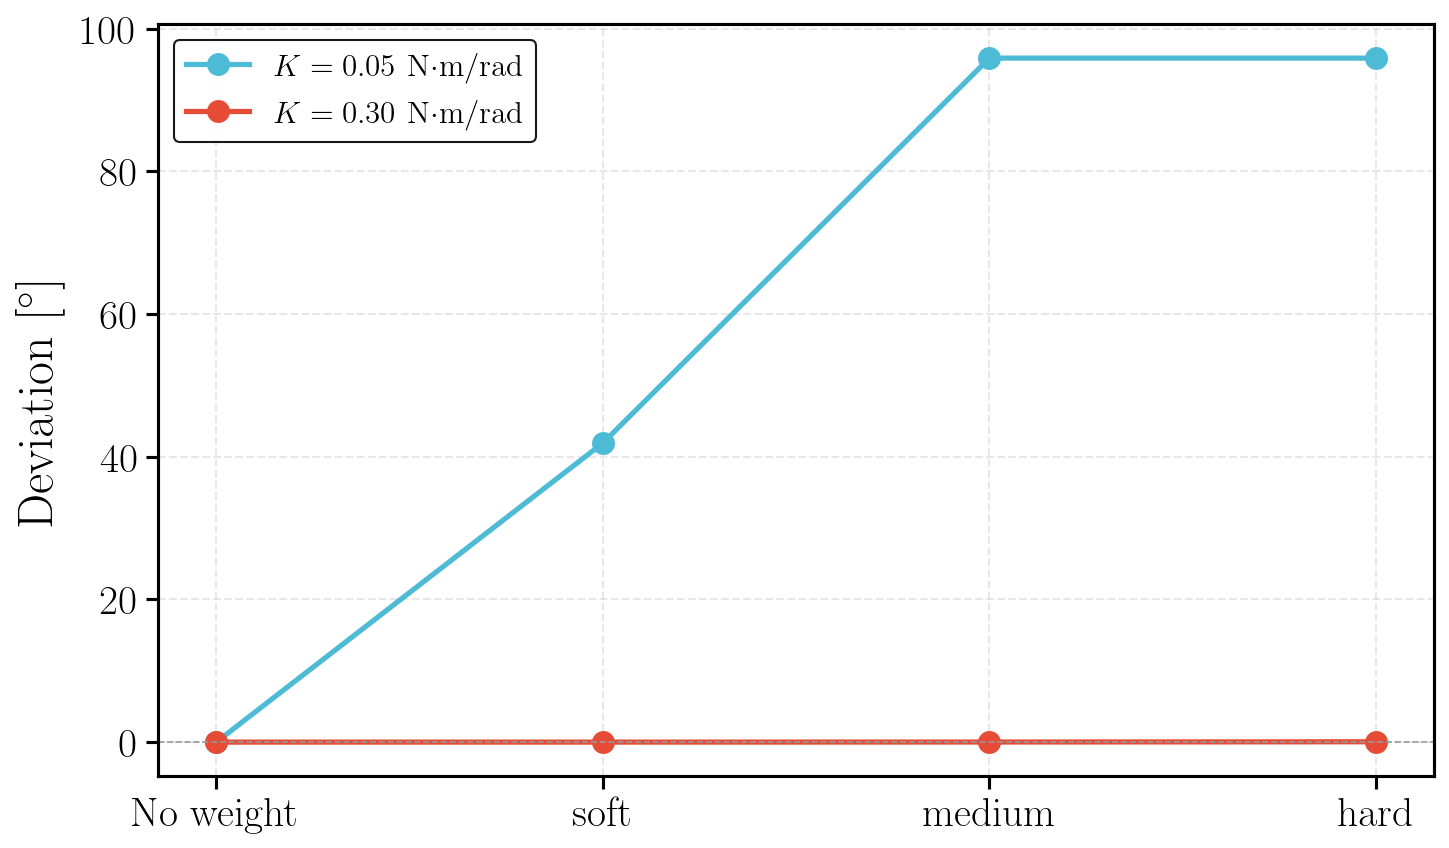

In [2]:
fig, ax = plt.subplots()

steps = list(range(N_STEPS))

for i, k in enumerate(STIFFNESS_CONDITIONS):
    d = DATA[k].copy()
    bls = {m: np.rad2deg(d[d['weight_step'] == 0][f'q_{m}'].astype(float).mean())
           for m in IDX_MOTORS}
    devs = []
    for s in steps:
        rows = d[d['weight_step'] == s]
        total = sum(abs(bls[m] - np.rad2deg(rows[f'q_{m}'].astype(float)).mean())
                    for m in IDX_MOTORS)
        devs.append(total)
    ax.plot(steps, devs, 'o-', color=COLORS[i % len(COLORS)],
            label=rf'$K = {k:.2f}$ N$\cdot$m/rad')

ax.axhline(0, color='0.6', lw=0.8, ls='--')
ax.set_xticks(steps)
ax.set_xticklabels(['No weight'] + WEIGHT_LABELS)
ax.set_ylabel(r'Deviation [$^\circ$]')
ax.legend(loc='upper left', fontsize='small')
if DEMO:
    fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
             ha='center', va='center', rotation=30, zorder=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'weight_deviation_vs_step.pdf'), dpi=300)
plt.show()
